# Section 03
# Import Libraries

In [11]:
import cv2
import numpy as np
import albumentations as A
import matplotlib.pyplot as plt
import random


# 01) Enhanced Top-Hat Vessel Enhancement

In [2]:
def enhanced_tophat_filter(
    img,
    kernel_ratio=0.04,
    apply_clahe=True
):
    """
    Enhanced Top-hat filtering for angiogram vessel enhancement.
    
    Parameters:
    - img: Grayscale image (numpy array, uint8)
    - kernel_ratio: Relative kernel size based on image width
    - apply_clahe: Whether to apply CLAHE after top-hat
    
    Returns:
    - Vessel-enhanced image (uint8)
    """

    # Ensure grayscale numpy array
    if not isinstance(img, np.ndarray):
        img = np.array(img)

    img = img.astype(np.uint8)

    # Adaptive kernel size
    k = int(img.shape[1] * kernel_ratio)
    k = max(15, k | 1)  # ensure odd size

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))

    # White and black top-hat
    white_tophat = cv2.morphologyEx(img, cv2.MORPH_TOPHAT, kernel)
    black_tophat = cv2.morphologyEx(img, cv2.MORPH_BLACKHAT, kernel)

    # Vessel enhancement formula
    enhanced = cv2.add(img, white_tophat)
    enhanced = cv2.subtract(enhanced, black_tophat)

    #  CLAHE for local contrast
    if apply_clahe:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        enhanced = clahe.apply(enhanced)

    return enhanced


# 02) Angiogram Data Augmentation Pipeline

In [3]:
angiogram_augmentation = A.Compose([
    # Safe anatomical rotation
    A.RandomRotate90(p=0.8),

    # Simulate dye diffusion & acquisition variability
    A.RandomGamma(gamma_limit=(80, 130), p=0.6),

    # Brightness & contrast variation
    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.6
    ),

    # X-ray noise simulation
    A.GaussNoise(var_limit=(5.0, 20.0), p=0.4),

], p=1.0)


C:\Users\User\AppData\Local\Temp\ipykernel_18920\3966073202.py:16: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 20.0), p=0.4),


# 03) Apply Angiogram Augmentation

In [4]:
def apply_angiogram_augmentation(img):
    """
    Apply image augmentation to a vessel-enhanced angiogram image.

    Parameters:
    - img: uint8 grayscale image (numpy array)

    Returns:
    - Augmented image (uint8)
    """
    augmented = angiogram_augmentation(image=img)
    return augmented["image"]


# 04)  Full Angiogram Preprocessing Pipeline

In [5]:
def preprocess_angiogram_image(img_gray):
    """
    Full angiogram preprocessing pipeline.

    Steps:
    1. Enhanced top-hat filtering
    2. Image augmentation

    Parameters:
    - img_gray: Grayscale angiogram image (uint8)

    Returns:
    - Final preprocessed image (uint8)
    """

    # Step 1: Vessel enhancement
    enhanced = enhanced_tophat_filter(
        img_gray,
        kernel_ratio=0.04,
        apply_clahe=True
    )

    # Step 2: Augmentation
    augmented = apply_angiogram_augmentation(enhanced)

    return augmented


# 05) Batch Preprocessing of Angiogram Images

In [6]:
from pathlib import Path
from tqdm import tqdm

def batch_preprocess_angiograms(
    input_dir,
    output_dir,
    img_exts=(".png", ".jpg", ".jpeg")
):
    """
    Batch preprocess angiogram images.

    Parameters:
    - input_dir: Folder with normalized angiogram images
    - output_dir: Folder to save preprocessed images
    """

    input_dir = Path(input_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    image_paths = []
    for ext in img_exts:
        image_paths.extend(input_dir.glob(f"*{ext}"))

    for img_path in tqdm(image_paths, desc="Angiogram preprocessing"):
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        processed = preprocess_angiogram_image(img)

        cv2.imwrite(str(output_dir / img_path.name), processed)

    print("[DONE] Angiogram preprocessing + augmentation completed.")


# 06) Output

In [7]:
INPUT_FOLDER = "C:/Users/User/Desktop/Angiogram_Preprocessing_Step_01"
OUTPUT_FOLDER = "C:/Users/User/Desktop/Final Angiogram Preprocessed Output"

batch_preprocess_angiograms(INPUT_FOLDER, OUTPUT_FOLDER)


Angiogram preprocessing: 100%|██████████| 1000/1000 [00:26<00:00, 37.54it/s]

[DONE] Angiogram preprocessing + augmentation completed.


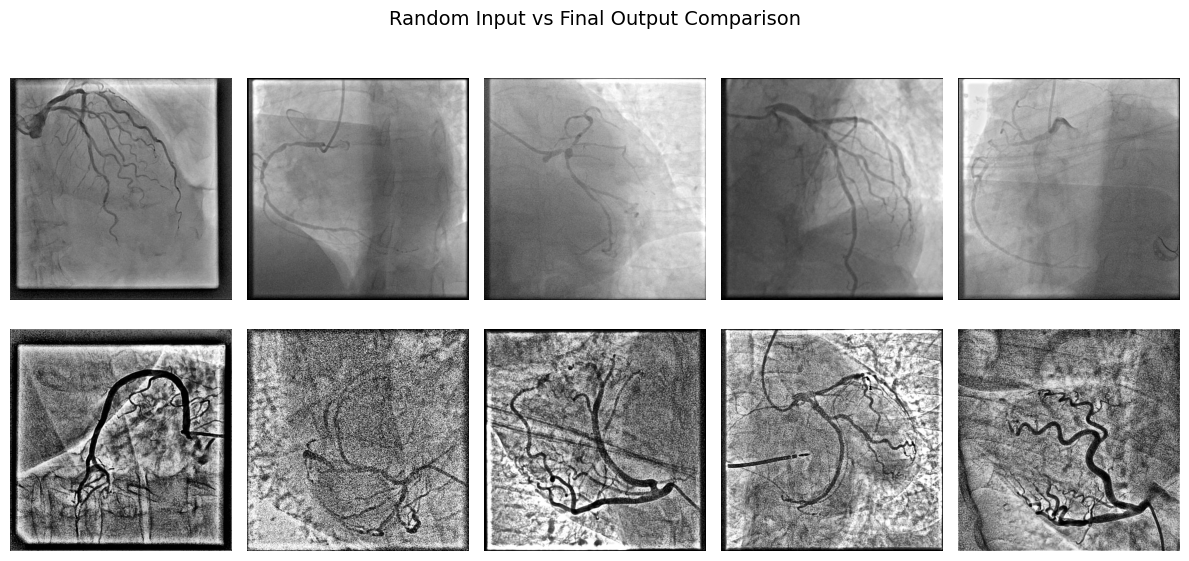

In [19]:
INPUT_FOLDER = Path("C:/Users/User/Desktop/Angiogram_Preprocessing_Step_01")
OUTPUT_FOLDER = Path("C:/Users/User/Desktop/Final Angiogram Preprocessed Output")

# Collect images
input_imgs = list(INPUT_FOLDER.glob("*.png")) + list(INPUT_FOLDER.glob("*.jpg"))
final_imgs = list(OUTPUT_FOLDER.glob("*.png")) + list(OUTPUT_FOLDER.glob("*.jpg"))

# Pick up to 5 random pairs (input + output)
n = min(5, len(input_imgs), len(final_imgs))
input_sample = random.sample(input_imgs, n)
final_sample = random.sample(final_imgs, n)

plt.figure(figsize=(12, 6))  # 2 rows, 5 columns

# Top row: input images
for i, p in enumerate(input_sample):
    plt.subplot(2, 5, i + 1)
    img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.ylabel("INPUT", fontsize=12)

# Bottom row: output images
for i, p in enumerate(final_sample):
    plt.subplot(2, 5, i + 6)  # second row starts at index 6
    img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.ylabel("OUTPUT", fontsize=12)

plt.suptitle("Random Input vs Final Output Comparison", fontsize=14)
plt.tight_layout()
plt.show()